# Compare paper's base model vs tuned model vs MWPM

Loads TWO trained checkpoints (produced by `decoder/train.py`) (the fixed
"paper's base model" config (`base_model.json`) and one trial from the `tune.py` search) and compares them to each other and to MWPM in three way.
First two ways re-use the exat same trained model and the third one re-trains the model one on each new dataset used in the second. This is to see that

1. **In-distribution**: on freshly drawn syndromes from the exact circuit both
   models were trained on. Evaluates the trained models.

2. **Zero-shot generalization**: on syndromes drawn from *other* circuits
   (different `p`) that neither model ever saw during training -- no
   retraining involved. MWPM is rebuilt fresh for each circuit since it
   doesn't need training to be near-optimal at any `p`.
3. **Retrained / in-distribution at each p:** for each new circuit/noise rate used in the zero-shot experiment, a new model is trained from scratch on data generated from that same circuit and then evaluated on unseen samples from that distribution. This measures how well the model performs when it is allowed to train specifically for each noise rate.
Set `PAPERS_BASE_MODEL_DIR` and `TUNED_DIR` below to the two run directories to compare.

In [2]:
import json
import os
import sys

import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import binomtest

# decoder/ holds model.py and train.py -- reuse them instead of redefining
# the architecture/dataset/split logic here.
sys.path.append(os.path.join("..", "decoder"))
from model import build_model
from train import load_dataset, make_loaders, get_device
from mwpm_reference import load_metadata, build_matcher

# data/ holds generate_datasets.py -- reuse the exact circuit/sampler code
# used to build the training datasets.
sys.path.append(os.path.join("..", "data"))
from generate_datasets import create_circuit, create_sampler, sample as draw_samples

## Load both configs

`PAPERS_BASE_MODEL_DIR` and `TUNED_DIR` must each contain `config.json` + `metrics.json`
+ `model.pth`, written by `decoder/train.py` 

In [24]:
# Path to the two run directories to compare (must each contain
# config.json / metrics.json / model.pth, written by decoder/train.py)
PAPERS_BASE_MODEL_DIR = "./final_training/FT/d5/005" # change with path to paper's base model run
TUNED_DIR = "./final_training/FT/d5/01" # change with best trial of tune

def load_run(run_dir):
    with open(os.path.join(run_dir, "config.json")) as f:
        config = json.load(f)
    with open(os.path.join(run_dir, "metrics.json")) as f:
        metrics = json.load(f)
    return config, metrics


papers_base_model_config, papers_base_model_metrics = load_run(PAPERS_BASE_MODEL_DIR)
tuned_config, tuned_metrics = load_run(TUNED_DIR)

print("Paper's base model config:", json.dumps(papers_base_model_config, indent=2))
print(f'Paper\'s base model best val accuracy: {papers_base_model_metrics["best_val_accuracy"]:.4f} (epoch {papers_base_model_metrics["best_epoch"]})')
print()
print("Tuned config:", json.dumps(tuned_config, indent=2))
print(f'Tuned best val accuracy: {tuned_metrics["best_val_accuracy"]:.4f} (epoch {tuned_metrics["best_epoch"]})')

Paper's base model config: {
  "hidden_sizes": [
    256,
    128,
    64
  ],
  "dropout": [
    0.3,
    0.0,
    0.0
  ],
  "lr": 0.0003,
  "dataset_path": "/home/vfairon/Documents/Cours/Q9/Stage/adversarial-blind-spots-in-quantum-error-correction-mlp-decoder/tuning_vic/final_training/FT/d5/005/data/dataset.npz",
  "seed": 197374205,
  "epochs": 60
}
Paper's base model best val accuracy: 0.8958 (epoch 60)

Tuned config: {
  "hidden_sizes": [
    256,
    128,
    64
  ],
  "dropout": [
    0.3,
    0.0,
    0.0
  ],
  "lr": 0.0003,
  "dataset_path": "/home/vfairon/Documents/Cours/Q9/Stage/adversarial-blind-spots-in-quantum-error-correction-mlp-decoder/tuning_vic/final_training/FT/d5/01/data/dataset.npz",
  "seed": 197374205,
  "epochs": 60
}
Tuned best val accuracy: 0.6637 (epoch 60)


## Training curves

Train vs validation BCE loss per epoch for both runs -- watch the gap between
train and val loss widen (overfitting, more capacity/epochs than the data
supports) or stay flat (still generalizing).

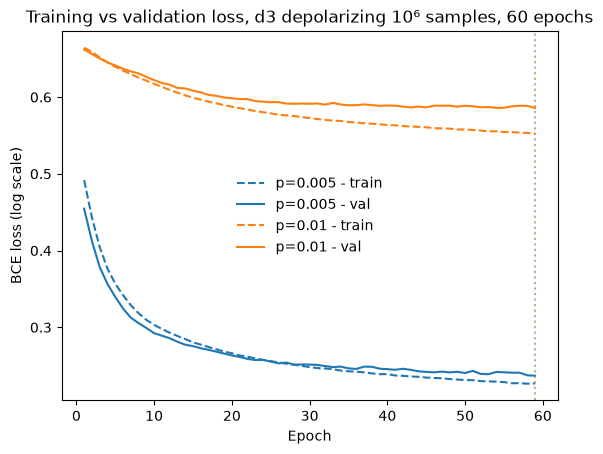

In [ ]:
start_epoch = 1

plt.figure()
for name, metrics, color in [
    ("paper's base model", papers_base_model_metrics, "C0"),
    ("tuned", tuned_metrics, "C1"),
]:
    train_losses = metrics["train_losses"][start_epoch:]
    val_losses = metrics["val_losses"][start_epoch:]
    epochs = np.arange(start_epoch, start_epoch + len(train_losses))
    if name == "tuned":
        name = "p=0.01"
    else:
        name = "p=0.005"
    plt.plot(epochs, train_losses, color=color, linestyle="--", label=f"{name} - train")
    plt.plot(epochs, val_losses, color=color, linestyle="-", label=f"{name} - val")

    if metrics["best_epoch"] > start_epoch:
        plt.axvline(metrics["best_epoch"] - 1, color=color, linestyle=":", alpha=0.4)

# plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("BCE loss (log scale)")
plt.title("Training vs validation loss, d5 depolarizing 10⁶ samples, 60 epochs")
plt.legend(frameon=False)
plt.show()

## Rebuild both models

Both configs must have been trained on the *same* dataset (same circuit) for
the in-distribution comparison in Part 1 to be meaningful -- checked below.

In [6]:
print("Paper's base model dataset:", papers_base_model_config["dataset_path"])
print("Tuned model dataset:", tuned_config["dataset_path"])

# assert papers_base_model_config["dataset_path"] == tuned_config["dataset_path"], (
#     "Paper's base model and tuned model were trained on different datasets -- "
#     "the in-distribution comparison in Part 1 would not be apples-to-apples.\n"
#     f"paper base dataset: {papers_base_model_config['dataset_path']}\n"
#     f"tuned dataset: {tuned_config['dataset_path']}"
# )

device = get_device()
print("Using device:", device)

# Both models share the same input dimension since they were trained on the
train_dataset = load_dataset(papers_base_model_config["dataset_path"])
input_size = train_dataset.features.shape[1]


def load_trained_model(run_dir, config, input_size, device):
    model = build_model(config, input_size).to(device)
    model.load_state_dict(torch.load(os.path.join(run_dir, "model.pth"), map_location=device))
    model.eval()
    return model


models = {
    "paper's base model": load_trained_model(PAPERS_BASE_MODEL_DIR, papers_base_model_config, input_size, device),
    "tuned": load_trained_model(TUNED_DIR, tuned_config, input_size, device),
}

Paper's base model dataset: /home/vfairon/Documents/Cours/Q9/Stage/adversarial-blind-spots-in-quantum-error-correction-mlp-decoder/tuning_vic/final_training/FT/d3/005/data/dataset.npz
Tuned model dataset: /home/vfairon/Documents/Cours/Q9/Stage/adversarial-blind-spots-in-quantum-error-correction-mlp-decoder/tuning_vic/final_training/FT/d3/01/data/dataset.npz
Using device: cuda


## Shared evaluation helper

`evaluate_circuit_all_models` draws fresh syndromes from a given circuit
(several independent seeds) and evaluates every model in `models` **as-is**
(no retraining) plus MWPM (rebuilt fresh for that circuit)

In [7]:
EVAL_SEEDS = list(range(1000, 1010))  # 10 independent eval sets, distinct from any training seed
N_SAMPLES_PER_SEED = 1_000_000
EVAL_BATCH_SIZE = 200_000  # minibatch the MLP forward pass to bound GPU memory


def predict_in_batches(model, features, device, batch_size=EVAL_BATCH_SIZE):
    """Run model(features) in chunks so a 1M-shot eval set doesn't blow up GPU memory in one forward pass."""
    preds_chunks = []
    with torch.no_grad():
        for i in range(0, len(features), batch_size):
            chunk = torch.from_numpy(features[i:i + batch_size]).to(device)
            logits = model(chunk).squeeze(-1)
            preds_chunks.append((logits > 0.0).float().cpu().numpy())
    return np.concatenate(preds_chunks)


def evaluate_circuit_all_models(label, metadata_path, models, device, verbose=True):
    """
    Draw fresh syndromes from the circuit described by metadata_path, evaluate
    every model in `models` (dict name -> torch model, already trained,
    evaluated as-is) plus a freshly-built MWPM matcher for that circuit.

    Returns a dict:
        {
            "label": label,
            "pooled_ler": {"MWPM": float, <model_name>: float, ...},
            "per_seed_ler": {"MWPM": [float, ...], <model_name>: [float, ...], ...},
            "pooled_preds": {"MWPM": np.ndarray, <model_name>: np.ndarray, ...},
            "labels": np.ndarray,
        }
    """
    circuit_metadata = load_metadata(metadata_path)
    circuit = create_circuit(**circuit_metadata)
    matcher = build_matcher(circuit)

    per_seed_ler = {name: [] for name in models}
    per_seed_ler["MWPM"] = []
    all_labels = []
    all_preds = {name: [] for name in models}
    all_preds["MWPM"] = []

    for seed in EVAL_SEEDS:
        sampler = create_sampler(circuit, seed=seed)
        seed_labels, seed_features = draw_samples(sampler, N_SAMPLES_PER_SEED)
        seed_labels_flat = seed_labels.reshape(-1)

        mwpm_preds = np.asarray(matcher.decode_batch(seed_features)).reshape(-1)
        mwpm_ler = (mwpm_preds != seed_labels_flat).mean()
        per_seed_ler["MWPM"].append(mwpm_ler)
        all_preds["MWPM"].append(mwpm_preds)

        for name, model in models.items():
            preds = predict_in_batches(model, seed_features, device)
            ler = (preds != seed_labels_flat).mean()
            per_seed_ler[name].append(ler)
            all_preds[name].append(preds)

        all_labels.append(seed_labels_flat)

        if verbose:
            seed_summary = ", ".join(f"{name}={per_seed_ler[name][-1]:.4%}" for name in per_seed_ler)
            print(f"[{label}] seed={seed}: {seed_summary}")

    labels_np = np.concatenate(all_labels)
    pooled_preds = {name: np.concatenate(p) for name, p in all_preds.items()}
    pooled_ler = {name: (pooled_preds[name] != labels_np).mean() for name in pooled_preds}

    if verbose:
        print(f"[{label}] pooled LER: " + ", ".join(f"{name}={pooled_ler[name]:.4%}" for name in pooled_ler))
        print()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "label": label,
        "pooled_ler": pooled_ler,
        "per_seed_ler": per_seed_ler,
        "pooled_preds": pooled_preds,
        "labels": labels_np,
    }


all_results = {}

## Part 1 -- On same circuit (all were trained on) (different draws) comparaison Paper's base model-Tuned-MWPM

Evaluate on the exact circuit both models were trained on (recovered from
`PAPERS_BASE_MODEL_DIR`'s dataset sidecar `.json`).

In [8]:
# get the circuit info corresponding to the training dataset so we can evaluate the models on the same circuit they were trained on
train_metadata_path = os.path.splitext(papers_base_model_config["dataset_path"])[0] + ".json"
train_circuit_metadata = load_metadata(train_metadata_path)
train_label = f"p={train_circuit_metadata['noise_default']} "

#add at the "p={train_circuit_metadata['noise_default']} (train)" the results of the eval of trained model on same circuits with different seeds
all_results[train_label] = evaluate_circuit_all_models(train_label, train_metadata_path, models, device)

Generating noise constants for noise model: circuit-level with default value: 0.005
########################################################
[p=0.005 ] seed=1000: paper's base model=4.7839%, tuned=4.3824%, MWPM=4.7137%
[p=0.005 ] seed=1001: paper's base model=4.7566%, tuned=4.3818%, MWPM=4.6970%
[p=0.005 ] seed=1002: paper's base model=4.7387%, tuned=4.3370%, MWPM=4.6723%
[p=0.005 ] seed=1003: paper's base model=4.8165%, tuned=4.3869%, MWPM=4.7462%
[p=0.005 ] seed=1004: paper's base model=4.7223%, tuned=4.3315%, MWPM=4.6712%
[p=0.005 ] seed=1005: paper's base model=4.7289%, tuned=4.3567%, MWPM=4.6659%
[p=0.005 ] seed=1006: paper's base model=4.7429%, tuned=4.3489%, MWPM=4.7087%
[p=0.005 ] seed=1007: paper's base model=4.7740%, tuned=4.3925%, MWPM=4.7256%
[p=0.005 ] seed=1008: paper's base model=4.7603%, tuned=4.3536%, MWPM=4.6952%
[p=0.005 ] seed=1009: paper's base model=4.7892%, tuned=4.3954%, MWPM=4.7086%
[p=0.005 ] pooled LER: paper's base model=4.7613%, tuned=4.3667%, MWPM=4.7004%


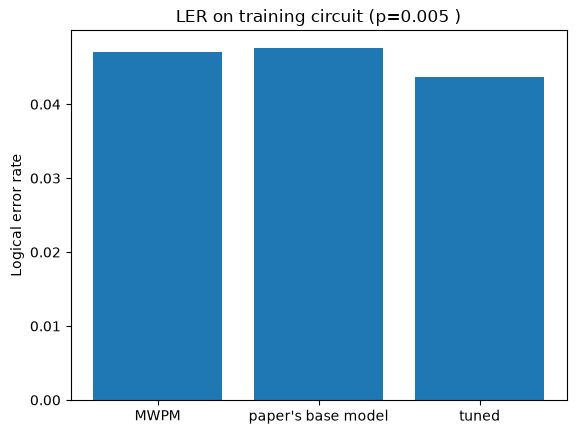

      MWPM: LER = 4.7004%
paper's base model: LER = 4.7613%
     tuned: LER = 4.3667%


In [9]:
result = all_results[train_label]
names = ["MWPM"] + list(models.keys())

plt.figure()
plt.bar(names, [result["pooled_ler"][n] for n in names])
plt.ylabel("Logical error rate")
plt.title(f"LER on training circuit ({train_label})")
plt.show()

for name in names:
    print(f"{name:>10}: LER = {result['pooled_ler'][name]:.4%}")

## Are paper's base model, tuned, and MWPM actually different?

McNemar's test, run pairwise between all three decoders on the training
circuit. E.g. for paper's base model vs tuned: H0: P(paper's base model correct, tuned wrong) =
P(paper's base model wrong, tuned correct). A small p-value means one of the two is
reliably better on the shots where they disagree, not just luckier overall.


In [10]:
def mcnemar_comparison(preds_a, preds_b, labels, name_a="A", name_b="B"):
    y_true = labels.astype(bool)
    a_wrong = preds_a.astype(bool) != y_true
    b_wrong = preds_b.astype(bool) != y_true

    both_wrong = np.sum(a_wrong & b_wrong)
    b_only = np.sum(~a_wrong & b_wrong)   # A right, B wrong
    c_only = np.sum(a_wrong & ~b_wrong)   # A wrong, B right
    n = len(y_true)

    print(f"both wrong           : {both_wrong} ({both_wrong/n:.4%})")
    print(f"{name_a} right, {name_b} wrong : {b_only}")
    print(f"{name_a} wrong, {name_b} right : {c_only}")

    if b_only + c_only > 0:
        p_value = binomtest(b_only, b_only + c_only, 0.5).pvalue
        print(f"McNemar's test: p-value = {p_value:.4g}")
        if p_value < 0.05:
            winner = name_a if b_only > c_only else name_b
            print(f"-> Significant at alpha=0.05: {winner} is reliably better on shots where they disagree.")
        else:
            print("-> Not significant at alpha=0.05: no reliable difference on shots where they disagree.")
    else:
        print(f"{name_a} and {name_b} never disagreed on any shot -- McNemar's test is undefined.")


print("--- paper's base model vs tuned ---")
mcnemar_comparison(
    result["pooled_preds"]["paper's base model"], result["pooled_preds"]["tuned"], result["labels"],
    name_a="paper's base model", name_b="tuned",
)

print("\n--- MWPM vs paper's base model ---")
mcnemar_comparison(
    result["pooled_preds"]["MWPM"], result["pooled_preds"]["paper's base model"], result["labels"],
    name_a="MWPM", name_b="paper's base model",
)

print("\n--- MWPM vs tuned ---")
mcnemar_comparison(
    result["pooled_preds"]["MWPM"], result["pooled_preds"]["tuned"], result["labels"],
    name_a="MWPM", name_b="tuned",
)

--- paper's base model vs tuned ---
both wrong           : 319009 (3.1901%)
paper's base model right, tuned wrong : 117658
paper's base model wrong, tuned right : 157124
McNemar's test: p-value = 0
-> Significant at alpha=0.05: tuned is reliably better on shots where they disagree.

--- MWPM vs paper's base model ---
both wrong           : 308758 (3.0876%)
MWPM right, paper's base model wrong : 167375
MWPM wrong, paper's base model right : 161286
McNemar's test: p-value = 2.413e-26
-> Significant at alpha=0.05: MWPM is reliably better on shots where they disagree.

--- MWPM vs tuned ---
both wrong           : 323419 (3.2342%)
MWPM right, tuned wrong : 113248
MWPM wrong, tuned right : 146625
McNemar's test: p-value = 0
-> Significant at alpha=0.05: tuned is reliably better on shots where they disagree.


## Part 2 -- On other circuits (generated by hand) no re-training.

Same two trained models (no retraining), evaluated on syndromes drawn from
**other** circuits at `d=3` depolarizing (different `p`). MWPM is rebuilt
fresh for each circuit

> This is the *zero-shot* question only ("how bad is the specialization gap if I don't retrain?"). The complementary *retrained* question ("how good could a model be on this circuit if I give it the chance to learn it?") is answered separately in Part 3 below.

In [47]:
OTHER_CIRCUITS = [
    ("p=0.001", "../tuning_vic/data/depol/d5/d3_1MIL/001/dataset.json"),
    ("p=0.003", "../tuning_vic/data/depol/d5/d3_1MIL/003/dataset.json"),
    # ("p=0.005", "../tuning_vic/data/depol/d5/d3_1MIL/005/dataset.json"),
    ("p=0.006", "../tuning_vic/data/depol/d5/d3_1MIL/006/dataset.json"),
    ("p=0.01", "../tuning_vic/data/depol/d5/d3_1MIL/01/dataset.json"),

]

for label, metadata_path in OTHER_CIRCUITS:
    all_results[label] = evaluate_circuit_all_models(label, metadata_path, models, device)

FileNotFoundError: [Errno 2] No such file or directory: '../tuning_vic/data/depol/d5/d3_1MIL/001/dataset.json'

### FT (circuit-level) alternative

Circuit-level FT noise has 4 independent probabilities instead of one scalar
`p`, so there's no single value to sweep the way `OTHER_CIRCUITS` does above.
Run the cell below **instead of** the `OTHER_CIRCUITS` cell above if `models`
were trained on FT noise -- it picks up every circuit already generated by
`generate_random_grid_datasets.sh` (the random `rand_XXX` draws plus the
fixed `all_005`/`all_01` points) and labels each by the *average* of its 4
probabilities (`p̄`), so the summary table / bar chart cells further down
work unchanged for either noise model.

In [16]:
import glob

FT_DISTANCE = train_circuit_metadata["distance"]  # matches whatever `models` were trained on
FT_DATA_DIR = f"../tuning_vic/data/FT/d{FT_DISTANCE}/1MIL"


def ft_circuit_avg_p(metadata_path):
    """Average of the 4 independent FT noise probabilities recorded in a dataset's .json."""
    meta = load_metadata(metadata_path)
    probs = [
        meta["after_clifford_depolarization"],
        meta["after_reset_flip_probability"],
        meta["before_measure_flip_probability"],
        meta["before_round_data_depolarization"],
    ]
    return sum(probs) / len(probs)


OTHER_CIRCUITS_FT = []
for circuit_dir in sorted(glob.glob(os.path.join(FT_DATA_DIR, "*"))):
    metadata_path = os.path.join(circuit_dir, "dataset.json")
    if not os.path.exists(metadata_path):
        continue
    name = os.path.basename(circuit_dir)
    avg_p = ft_circuit_avg_p(metadata_path)
    OTHER_CIRCUITS_FT.append((f"p̄={avg_p:.4f} ({name})", metadata_path))

for label, metadata_path in OTHER_CIRCUITS_FT:
    all_results[label] = evaluate_circuit_all_models(label, metadata_path, models, device)

Generating noise constants for noise model: circuit-level with default value: 0.005
########################################################
[p̄=0.0050 (all_005)] seed=1000: paper's base model=4.7839%, tuned=4.3824%, MWPM=4.7137%
[p̄=0.0050 (all_005)] seed=1001: paper's base model=4.7566%, tuned=4.3818%, MWPM=4.6970%
[p̄=0.0050 (all_005)] seed=1002: paper's base model=4.7387%, tuned=4.3370%, MWPM=4.6723%
[p̄=0.0050 (all_005)] seed=1003: paper's base model=4.8165%, tuned=4.3869%, MWPM=4.7462%
[p̄=0.0050 (all_005)] seed=1004: paper's base model=4.7223%, tuned=4.3315%, MWPM=4.6712%
[p̄=0.0050 (all_005)] seed=1005: paper's base model=4.7289%, tuned=4.3567%, MWPM=4.6659%
[p̄=0.0050 (all_005)] seed=1006: paper's base model=4.7429%, tuned=4.3489%, MWPM=4.7087%
[p̄=0.0050 (all_005)] seed=1007: paper's base model=4.7740%, tuned=4.3925%, MWPM=4.7256%
[p̄=0.0050 (all_005)] seed=1008: paper's base model=4.7603%, tuned=4.3536%, MWPM=4.6952%
[p̄=0.0050 (all_005)] seed=1009: paper's base model=4.7892

## Summary across circuits


In [17]:
# Order circuits by physical error rate (parsed back out of the label) so the
# table/plot read left-to-right from easiest to hardest.
ordered_labels = sorted(all_results.keys(), key=lambda l: float(l.split("=")[1].split(" ")[0]))
decoder_names = ["MWPM"] + list(models.keys())

header = f"{'circuit':>14} | " + " | ".join(f"{name:>10}" for name in decoder_names)
print(header)
print("-" * len(header))
for label in ordered_labels:
    row = all_results[label]["pooled_ler"]
    print(f"{label:>14} | " + " | ".join(f"{row[name]:.4%}".rjust(10) for name in decoder_names))

       circuit |       MWPM | paper's base model |      tuned
-------------------------------------------------------------
p̄=0.0047 (rand_010) |    3.2304% |    3.0080% |    2.8547%
      p=0.005  |    4.7004% |    4.7613% |    4.3667%
p̄=0.0050 (all_005) |    4.7004% |    4.7613% |    4.3667%
p̄=0.0050 (rand_006) |    8.9803% |    9.0847% |    8.6067%
p̄=0.0050 (rand_009) |    4.1323% |    4.1167% |    3.7835%
p̄=0.0055 (rand_004) |    2.8203% |    2.8489% |    2.5386%
p̄=0.0060 (rand_008) |    8.9210% |    9.2174% |    8.5614%
p̄=0.0063 (rand_003) |    6.3148% |    7.0451% |    6.1466%
p̄=0.0067 (rand_001) |    7.2678% |    7.7377% |    6.9664%
p̄=0.0067 (rand_007) |    7.9485% |    8.5721% |    7.7158%
p̄=0.0077 (rand_002) |   10.7692% |   11.9022% |   10.6678%
p̄=0.0085 (rand_005) |    8.3922% |    9.1778% |    8.1375%
p̄=0.0100 (all_010) |   15.0210% |   16.8021% |   15.1147%


MWPM
old
new


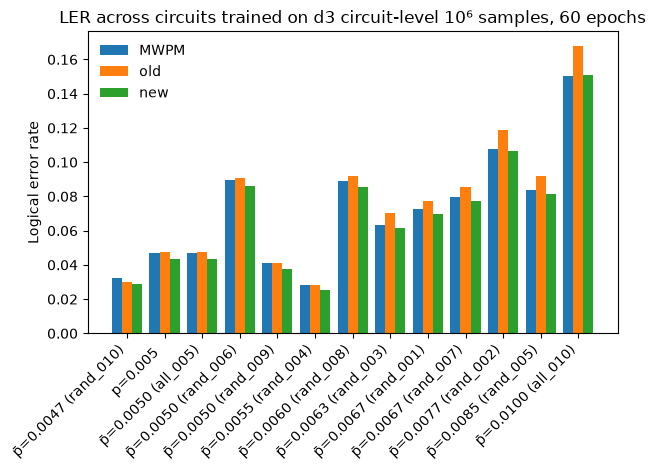

In [ ]:
x = np.arange(len(ordered_labels))
width = 0.8 / len(decoder_names)

plt.figure()
for i, name in enumerate(decoder_names):
    values = [all_results[label]["pooled_ler"][name] for label in ordered_labels]
    if name == "tuned":
        name = "trained on p=0.01"
    if name == "paper's base model":
        name = "trained on p=0.005"
    plt.bar(x + i * width, values, width=width, label=name)
    print(name)

plt.xticks(x + width * (len(decoder_names) - 1) / 2, ordered_labels, rotation=45, ha="right")
plt.ylabel("Logical error rate")
plt.title(f"LER across circuits trained on d{train_circuit_metadata['distance']} {train_circuit_metadata['noise_type']} 10⁶ samples, 60 epochs")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

## Are the differences significant on every circuit?

Same pairwise McNemar tests as Part 1, but repeated for every circuit in
`all_results` (training circuit + the zero-shot ones) -- lets you check
whether a significant paper's base model/tuned/MWPM difference in-distribution survives,
appears, or disappears once the models are evaluated out of distribution.

In [ ]:
for label in ordered_labels:
    r = all_results[label]
    print(f"===== {label} =====")

    print("--- paper's base model vs tuned ---")
    mcnemar_comparison(r["pooled_preds"]["paper's base model"], r["pooled_preds"]["tuned"], r["labels"],
                        name_a="paper's base model", name_b="tuned")

    print("\n--- MWPM vs paper's base model ---")
    mcnemar_comparison(r["pooled_preds"]["MWPM"], r["pooled_preds"]["paper's base model"], r["labels"],
                        name_a="MWPM", name_b="paper's base model")

    print("\n--- MWPM vs tuned ---")
    mcnemar_comparison(r["pooled_preds"]["MWPM"], r["pooled_preds"]["tuned"], r["labels"],
                        name_a="MWPM", name_b="tuned")
    print()

===== p=0.001 =====
--- paper's base model vs tuned ---
both wrong           : 4 (0.0000%)
paper's base model right, tuned wrong : 1
paper's base model wrong, tuned right : 7
McNemar's test: p-value = 0.07031
-> Not significant at alpha=0.05: no reliable difference on shots where they disagree.

--- MWPM vs paper's base model ---
both wrong           : 3 (0.0000%)
MWPM right, paper's base model wrong : 8
MWPM wrong, paper's base model right : 1
McNemar's test: p-value = 0.03906
-> Significant at alpha=0.05: MWPM is reliably better on shots where they disagree.

--- MWPM vs tuned ---
both wrong           : 3 (0.0000%)
MWPM right, tuned wrong : 2
MWPM wrong, tuned right : 1
McNemar's test: p-value = 1
-> Not significant at alpha=0.05: no reliable difference on shots where they disagree.

===== p=0.005 =====
--- paper's base model vs tuned ---
both wrong           : 951 (0.0095%)
paper's base model right, tuned wrong : 337
paper's base model wrong, tuned right : 802
McNemar's test: p-valu

## Part 3 -- Retrained on other circuits (fair per-circuit comparison)

Part 2 answers *"how bad is it if I reuse these exact weights elsewhere?"* --
useful for measuring specialization, but not a fair test of whether the
**paper's base model**/**tuned** hyperparameter configs themselves are good choices for
other circuits.

This part answers the complementary question: keep the same `hidden_sizes`/
`dropout`/`lr` config, but give each circuit its own **freshly trained**
model (same recipe as `base_training_015`/`TUNED_DIR`, just pointed at a
different `--dataset`). MWPM needs no such step -- it's already rebuilt fresh
per circuit in `evaluate_circuit_all_models`.

Training is skipped (and the existing checkpoint reused) if
`retrained_<name>/model.pth` already exists next to a circuit's dataset, so
re-running this cell is cheap after the first time.

In [ ]:
from train import train as train_model


def get_or_train_model(config, dataset_path, output_dir, epochs, seed, input_size, device, verbose=True):
    """Train a config on dataset_path into output_dir unless a checkpoint is already there, then load it."""
    checkpoint_path = os.path.join(output_dir, "model.pth")
    if not os.path.exists(checkpoint_path):
        if verbose:
            print(f"Training into {output_dir} (dataset={dataset_path}) ...")
        train_model(config, dataset_path, output_dir, epochs=epochs, seed=seed, verbose=verbose)
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    else:
        if verbose:
            print(f"Found existing checkpoint, skipping training: {checkpoint_path}")
    return load_trained_model(output_dir, config, input_size, device)


retrained_results = {}

for label, metadata_path in OTHER_CIRCUITS:
    circuit_dataset_path = os.path.splitext(metadata_path)[0] + ".npz"
    circuit_dir = os.path.dirname(metadata_path)

    papers_base_model_retrained = get_or_train_model(
        papers_base_model_config, circuit_dataset_path, os.path.join(circuit_dir, "retrained_papers_base_model"),
        epochs=papers_base_model_config.get("epochs", 30), seed=papers_base_model_config.get("seed", 42),
        input_size=input_size, device=device,
    )
    tuned_retrained = get_or_train_model(
        tuned_config, circuit_dataset_path, os.path.join(circuit_dir, "retrained_tuned"),
        epochs=tuned_config.get("epochs", 30), seed=tuned_config.get("seed", 42),
        input_size=input_size, device=device,
    )

    retrained_models = {"paper's base model (retrained)": papers_base_model_retrained, "tuned_retrained": tuned_retrained}
    retrained_results[label] = evaluate_circuit_all_models(label, metadata_path, retrained_models, device)

Training into ../tuning_vic/d5/001/retrained_papers_base_model (dataset=../tuning_vic/d5/001/dataset.npz) ...
Using device: cuda
Epoch 1/60: train_loss=0.0355 val_loss=0.0016 val_acc=0.9994
Epoch 2/60: train_loss=0.0013 val_loss=0.0008 val_acc=0.9999
Epoch 3/60: train_loss=0.0008 val_loss=0.0006 val_acc=0.9999
Epoch 4/60: train_loss=0.0007 val_loss=0.0007 val_acc=0.9999
Epoch 5/60: train_loss=0.0006 val_loss=0.0006 val_acc=0.9999
Epoch 6/60: train_loss=0.0005 val_loss=0.0006 val_acc=0.9999
Epoch 7/60: train_loss=0.0005 val_loss=0.0007 val_acc=0.9999
Epoch 8/60: train_loss=0.0005 val_loss=0.0007 val_acc=0.9999
Epoch 9/60: train_loss=0.0004 val_loss=0.0007 val_acc=0.9999
Epoch 10/60: train_loss=0.0003 val_loss=0.0004 val_acc=0.9999
Epoch 11/60: train_loss=0.0002 val_loss=0.0006 val_acc=0.9999
Epoch 12/60: train_loss=0.0001 val_loss=0.0007 val_acc=0.9999
Epoch 13/60: train_loss=0.0002 val_loss=0.0007 val_acc=0.9999
Epoch 14/60: train_loss=0.0001 val_loss=0.0008 val_acc=0.9999
Epoch 15/60:

RuntimeError: Error(s) in loading state_dict for Sequential:
	size mismatch for fc1.weight: copying a param with shape torch.Size([512, 216]) from checkpoint, the shape in current model is torch.Size([1024, 216]).
	size mismatch for fc1.bias: copying a param with shape torch.Size([512]) from checkpoint, the shape in current model is torch.Size([1024]).
	size mismatch for fc2.weight: copying a param with shape torch.Size([256, 512]) from checkpoint, the shape in current model is torch.Size([512, 1024]).
	size mismatch for fc2.bias: copying a param with shape torch.Size([256]) from checkpoint, the shape in current model is torch.Size([512]).
	size mismatch for fc3.weight: copying a param with shape torch.Size([128, 256]) from checkpoint, the shape in current model is torch.Size([256, 512]).
	size mismatch for fc3.bias: copying a param with shape torch.Size([128]) from checkpoint, the shape in current model is torch.Size([256]).
	size mismatch for fc4.weight: copying a param with shape to

### Zero-shot vs retrained, side by side

For each of the two other circuits: MWPM (always near-optimal), the two
zero-shot models (from Part 2, trained only on `p=0.015`), and the two
freshly-retrained models (Part 3, trained specifically for that circuit).

In [ ]:
papers_base_model_label = "paper's base model"

header = f"{'circuit':>10} | {'MWPM':>10} | {papers_base_model_label + ' (0-shot)':>27} | {papers_base_model_label + ' (retrain)':>28} | {'tuned (0-shot)':>15} | {'tuned (retrain)':>16}"
print(header)
print("-" * len(header))
for label, _ in OTHER_CIRCUITS:
    zs = all_results[label]["pooled_ler"]
    rt = retrained_results[label]["pooled_ler"]
    zs_base = zs[papers_base_model_label]
    rt_base = rt[papers_base_model_label + " (retrained)"]
    print(
        f"{label:>10} | {zs['MWPM']:>10.4%} | {zs_base:>27.4%} | {rt_base:>28.4%} "
        f"| {zs['tuned']:>15.4%} | {rt['tuned_retrained']:>16.4%}"
    )

In [ ]:
# Plot retrained performance for each p with methods side by side
labels = [label for label, _ in OTHER_CIRCUITS]
methods = ["MWPM", "paper's base model (retrained)", "tuned_retrained"]

x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(8, 5))

for i, method in enumerate(methods):
    values = [retrained_results[label]["pooled_ler"][method] for label in labels]
    plt.bar(x + (i - 1) * width, values, width=width, label=method)

plt.xticks(x, labels)
plt.ylabel("Logical error rate")
plt.title("Retrained model performance across circuits")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

## Reading the results

- On the **training circuit**, both MLPs should be close to (or better than)
  MWPM -- that's the in-distribution regime they were tuned/trained for.
- On the **other circuits**, watch how much each MLP's LER grows relative to
  MWPM's: MWPM is rebuilt per circuit so it stays near-optimal everywhere,
  while the MLPs only ever saw the training `p` -- any gap that opens up here
  is a measure of how much a fixed hyperparameter/model choice costs you
  outside its training regime, not a flaw in the tuning procedure itself.
- The per-circuit McNemar tests above tell you whether that gap (or the
  paper's base model/tuned gap) is actually statistically significant on each circuit,
  rather than just eyeballing the LER table/bar chart.
- **Part 3 vs Part 2**: if the retrained models in Part 3 close most of the gap Part 2's zero-shot models show against MWPM, the specialization gap was about the *weights*, not the *config* -- your chosen hyperparameters transfer fine, you just need to retrain per circuit (as planned for the main `(d, type, p)` experiment grid). If a gap remains even after retraining, that's evidence the config itself may need revisiting for that regime.
